In [1]:
import pickle
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

with open('C:/chem papers/TRAINED_MODELS/17_feat_LGBM_model.pkl', 'rb') as file: # import LGBM model
    LGBM_Model = pickle.load(file)

LGBM_Model

LGBMRegressor(boosting_type='goss', learning_rate=0.01, min_child_samples=2,
              min_child_weight=1.0, n_estimators=500, num_leaves=16,
              random_state=4, reg_alpha=0, reg_lambda=0.015, subsample=0.4)

In [2]:
# Import original dataset for standard scalar

datafile = "C:/chem papers/Dataset_17_feat.xlsx"
df = pd.read_excel(datafile)
X = df.drop(['Experimental_index','DP_Group','Release'],axis='columns')
stdScale = StandardScaler().fit(X)

In [3]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Import prediction excel file
datafile = "C:/chem papers/Prediction.xlsx"
df = pd.read_excel(datafile)

# Define features and targets
X = df.drop(['Experimental_index','DP_Group','Release','STD'], axis='columns')
Y = df['Release']
G = df['DP_Group']
STD = df['STD']

# Fit and transform with StandardScaler on the SAME X
stdScale = StandardScaler()
X_scale = stdScale.fit_transform(X)


In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Import prediction excel file
datafile = "C:/chem papers/Prediction.xlsx"
df = pd.read_excel(datafile)

# Define features and targets
X = df.drop(['Experimental_index','DP_Group','Release','STD'], axis='columns')
Y = df['Release']
G = df['DP_Group']
STD = df['STD']

# Get training features from model
train_features = LGBM_Model.feature_name_

# Align with training features (add missing ones as 0)
X = X.reindex(columns=train_features, fill_value=0)

# Scale
stdScale = StandardScaler()
X_scale = stdScale.fit_transform(X)

# Predict
y_pred = LGBM_Model.predict(X_scale)


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.


C:\Users\prajw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\prajw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\prajw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
 

In [ ]:
    df["predicted_release"] = y_pred
    df

,Experimental_index,DP_Group,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_LogP,Time,T=0.25,T=1.0,Release,STD,predicted_release
0,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,0.000000,0.005826,0.007976,0.000000,0.000000,0.634639
1,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,0.166667,0.005826,0.007976,0.003884,0.001019,0.634639
2,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,1.000000,0.005826,0.007976,0.007976,0.001134,0.634639
3,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,3.000000,0.005826,0.007976,0.011727,0.000628,0.634639
4,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,7.000000,0.005826,0.007976,0.017529,0.000281,0.634639
5,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,11.000000,0.005826,0.007976,0.031298,0.001289,0.634639
6,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,15.000000,0.005826,0.007976,0.093609,0.003203,0.634639
7,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,19.000000,0.005826,0.007976,0.609942,0.010562,0.634639
8,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,23.000000,0.005826,0.007976,0.953062,0.023455,0.634639
9,Prediction_1,OLA-PLGA,1,46000,0,208.5,9.96,0.666667,0.2889,73.982971,0.5,434.471,86.37,2.3474,27.000000,0.005826,0.007976,0.961734,0.025791,0.634639


Columns in dataset: Index(['Experimental_index', 'DP_Group', 'LA/GA', 'Polymer_MW', 'CL Ratio',
       'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE',
       'Drug_Mw', 'Drug_TPSA', 'Drug_LogP', 'Time', 'T=0.25', 'T=1.0',
       'Release', 'STD'],
      dtype='object')
  Experimental_index  DP_Group  LA/GA  Polymer_MW  CL Ratio  Drug_Tm  \
0       Prediction_1  OLA-PLGA      1       46000         0    208.5   
1       Prediction_1  OLA-PLGA      1       46000         0    208.5   
2       Prediction_1  OLA-PLGA      1       46000         0    208.5   
3       Prediction_1  OLA-PLGA      1       46000         0    208.5   
4       Prediction_1  OLA-PLGA      1       46000         0    208.5   

   Drug_Pka  Initial D/M ratio     DLC       SA-V   SE  Drug_Mw  Drug_TPSA  \
0      9.96           0.666667  0.2889  73.982971  0.5  434.471      86.37   
1      9.96           0.666667  0.2889  73.982971  0.5  434.471      86.37   
2      9.96           0.666667  0.2889  73.982

C:\Users\prajw\AppData\Local\Temp\ipykernel_19732\1212707933.py:46: RuntimeWarning: invalid value encountered in power
  return 1 - np.exp(-(((t - Ti) / a) ** b))


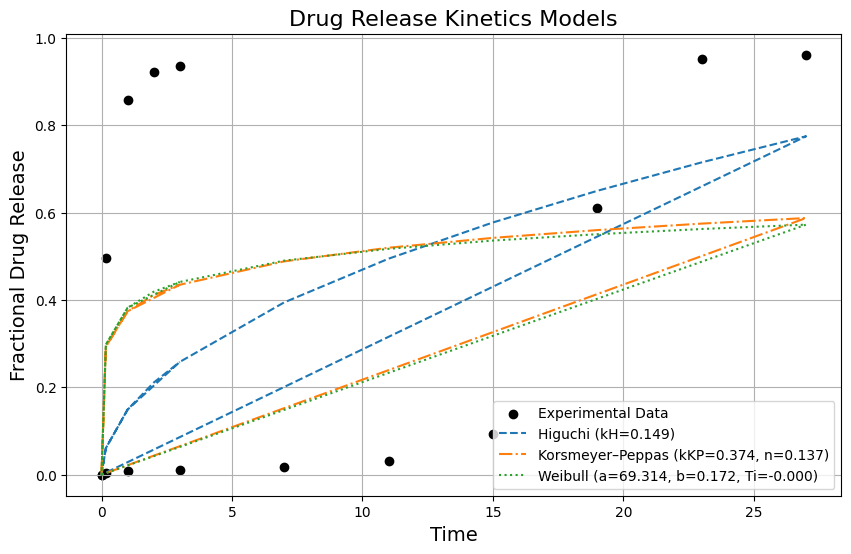

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ===============================
# 1. Load Dataset
# ===============================
file_path = "Prediction.xlsx"
df = pd.read_excel(file_path)

print("Columns in dataset:", df.columns)  # Debug print
print(df.head())  # Preview first rows

# Try to detect "Release" column (adjust name if different)
release_col = None
for col in df.columns:
    if "release" in col.lower():
        release_col = col
        break

if release_col is None:
    raise ValueError("No column found for release data! Please check Excel column names.")

time = df["Time"].values
release_exp = df[release_col].values

# Drop NaNs if any
mask = ~np.isnan(time) & ~np.isnan(release_exp)
time = time[mask]
release_exp = release_exp[mask]

print("Time values:", time)
print("Release values:", release_exp)

# ===============================
# 2. Define Models
# ===============================
def higuchi(t, kH):
    return kH * np.sqrt(t)

def korsmeyer_peppas(t, kKP, n):
    return kKP * (t ** n)

def weibull(t, a, b, Ti):
    return 1 - np.exp(-(((t - Ti) / a) ** b))

# ===============================
# 3. Fit Models
# ===============================
# Higuchi
popt_h, _ = curve_fit(higuchi, time, release_exp, p0=[0.5], maxfev=5000)
release_h = higuchi(time, *popt_h)

# Korsmeyer–Peppas
popt_kp, _ = curve_fit(korsmeyer_peppas, time, release_exp, p0=[0.5, 0.5], maxfev=5000)
release_kp = korsmeyer_peppas(time, *popt_kp)

# Weibull
popt_w, _ = curve_fit(weibull, time, release_exp, p0=[10, 1, 0], maxfev=5000)
release_w = weibull(time, *popt_w)

# ===============================
# 4. Plot
# ===============================
plt.figure(figsize=(10, 6))
plt.scatter(time, release_exp, color="black", label="Experimental Data")
plt.plot(time, release_h, label=f"Higuchi (kH={popt_h[0]:.3f})", linestyle="--")
plt.plot(time, release_kp, label=f"Korsmeyer–Peppas (kKP={popt_kp[0]:.3f}, n={popt_kp[1]:.3f})", linestyle="-.")
plt.plot(time, release_w, label=f"Weibull (a={popt_w[0]:.3f}, b={popt_w[1]:.3f}, Ti={popt_w[2]:.3f})", linestyle=":")

plt.xlabel("Time", fontsize=14)
plt.ylabel("Fractional Drug Release", fontsize=14)
plt.title("Drug Release Kinetics Models", fontsize=16)
plt.legend()
plt.grid(True)
plt.show()


In [18]:
# Identify all prediction columns (those starting with "T=")
pred_cols = [c for c in df.columns if c.startswith("T=")]

# Group by Experimental_index
grouped = df.groupby('Experimental_index')

DP_list = []
Time_list = []
EXP_list = []
PRED_list = []
STD_list = []

for name, group in grouped:
    # Actual experimental values
    Time_list.append(group['Time'])
    EXP_list.append(group['Release'])
    DP_list.append(group['DP_Group'])
    STD_list.append(group['STD'])

    # Collect predictions across all "T=" columns
    preds = group[pred_cols].values.flatten()
    PRED_list.append(preds)


 Predicted length mismatch for OLA-PLGA: time=10, pred=2 → interpolated
 Predicted length mismatch for SA-PLGA: time=5, pred=2 → interpolated


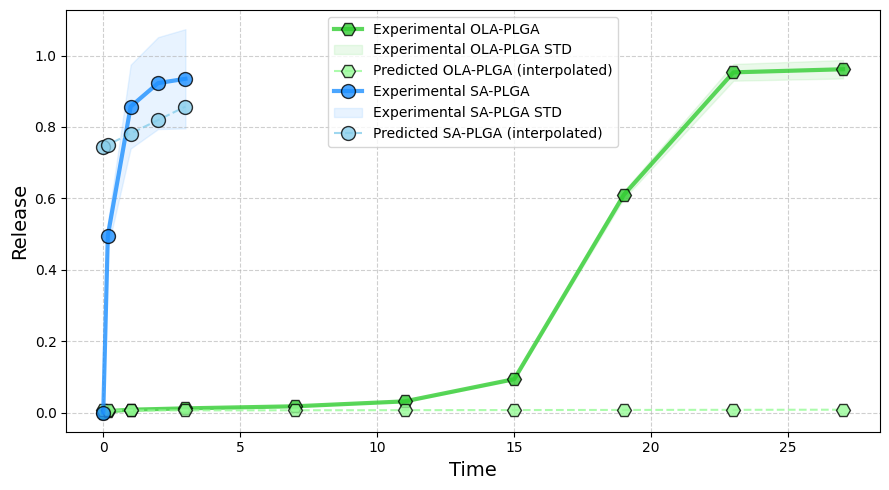

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))

def safe_plot_group(ax, time, exp, pred, std, dp_label, exp_color, pred_color, marker):
    """Plots experimental + predicted + error bars, with interpolation if needed."""
    # Ensure numpy arrays
    time = np.array(time)
    exp = np.array(exp)
    pred = np.array(pred)
    std = np.array(std)

    # Experimental
    if len(time) == len(exp):
        ax.plot(time, exp, label=f'Experimental {dp_label}',
                linestyle='-', linewidth=3, marker=marker, markersize=10,
                markeredgecolor="black", alpha=0.8, color=exp_color)
        ax.fill_between(time, exp - std, exp + std,
                        color=exp_color, alpha=0.1,
                        label=f'Experimental {dp_label} STD')
    else:
        print(f" Experimental length mismatch for {dp_label}: time={len(time)}, exp={len(exp)}")

    # Predicted
    if len(time) == len(pred):
        ax.plot(time, pred, label=f'Predicted {dp_label}',
                linestyle='--', linewidth=1.5, marker=marker, markersize=10,
                alpha=0.8, markeredgecolor="black", color=pred_color)
    else:
        pred_interp = np.interp(time,
                                np.linspace(time[0], time[-1], len(pred)),
                                pred)
        ax.plot(time, pred_interp, label=f'Predicted {dp_label} (interpolated)',
                linestyle='--', linewidth=1.5, marker=marker, markersize=10,
                alpha=0.8, markeredgecolor="black", color=pred_color)
        print(f" Predicted length mismatch for {dp_label}: time={len(time)}, pred={len(pred)} → interpolated")


# Define colors + markers (will cycle if groups > 4)
exp_colors = ["limegreen", "dodgerblue", "darkorange", "crimson"]
pred_colors = ["palegreen", "skyblue", "moccasin", "lightcoral"]
markers = ["H", "o", "s", "D"]  # Hexagon, circle, square, diamond

# Loop over however many groups you actually have
for i in range(len(Time_list)):
    # Make dp_label safe (Series, ndarray, or scalar)
    dp_group = DP_list[i]
    if hasattr(dp_group, "iloc"):   # Pandas Series
        dp_label = dp_group.iloc[0]
    elif isinstance(dp_group, (list, np.ndarray)):
        dp_label = dp_group[0]
    else:
        dp_label = str(dp_group)

    safe_plot_group(ax,
                    Time_list[i],
                    EXP_list[i],
                    PRED_list[i],
                    STD_list[i],
                    dp_label,
                    exp_colors[i % len(exp_colors)],
                    pred_colors[i % len(pred_colors)],
                    markers[i % len(markers)])


# ---- Formatting ----
ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Release", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()